## ISC 4242 Project

* Names: Matheus Santos Gomes, Joaquin Hidalgo, Rajan Jinadra

In [598]:
# Loading Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("heart_disease_uci.csv")

# preview
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [599]:
# Dropping ID column: 
df = df.drop('id', axis=1)

In [600]:
# Checking data types and missing values
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [601]:
# check missing values
print(df.isnull().sum())

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [602]:
# Checking for duplicates
df.duplicated().sum()

np.int64(2)

In [603]:
## Filling Missing values with Median and Mean

# numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# fill numerical with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# fill categorical with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/var/folders/ck/h6mn4h495ksc_5qds_00619c0000gn/T/ipykernel_32635/298235059.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/ck/h6mn4h495ksc_5qds_00619c0000gn/T/ipykernel_32635/298235059.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [604]:
# Recheck missing values
print(df.isnull().sum())

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


From the dataset:

| num | Meaning               |
| --- | --------------------- |
| 0   | No heart disease      |
| 1–4 | Heart disease present |


In [605]:
# Converting target variable to binary
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

df.head(10)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0
5,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0,0
6,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3,1
7,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0,0
8,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2,1
9,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1,1


After this change, we have:

| num | Meaning               |
| --- | --------------------- |
| 0   | No heart disease      |
| 1   | Heart disease present |


In [606]:
# Dropping original target column, so we only have the updated one on the dataset
df.drop('num', axis=1, inplace=True)

# Verifying
print("\nTarget Distribution:")
print(df['target'].value_counts())

print("\nTarget Distribution Percentage:")
print(df["target"].value_counts(normalize=True) * 100)


Target Distribution:
target
1    509
0    411
Name: count, dtype: int64

Target Distribution Percentage:
target
1    55.326087
0    44.673913
Name: proportion, dtype: float64


The target variable is relatively balanced, with approximately 55% of patients having heart disease and 45% not having it. \
This means that accuracy is a reliable metric, although precision, recall, and F1-score are still important for evaluating model performance.

In [607]:
# 4. Separate column types

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


# 5. Summary statistics

print("\nSummary Statistics:")
print(df.describe())

print("\nCategorical Summary:")
print(df.describe(include=["object", "bool"]))


Numerical Columns:
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target'], dtype='object')

Categorical Columns:
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

Summary Statistics:
              age    trestbps        chol      thalch     oldpeak          ca  \
count  920.000000  920.000000  920.000000  920.000000  920.000000  920.000000   
mean    53.510870  131.995652  199.908696  137.692391    0.853261    0.227174   
std      9.424685   18.451300  109.040171   25.145235    1.058049    0.628936   
min     28.000000    0.000000    0.000000   60.000000   -2.600000    0.000000   
25%     47.000000  120.000000  177.750000  120.000000    0.000000    0.000000   
50%     54.000000  130.000000  223.000000  140.000000    0.500000    0.000000   
75%     60.000000  140.000000  267.000000  156.000000    1.500000    0.000000   
max     77.000000  200.000000  603.000000  202.000000    6.200000    3.000000   

           target  
count  

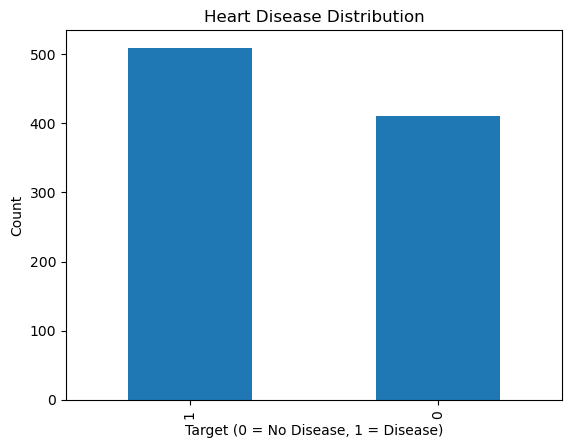

In [608]:
# Visualization of Target Variable Value Counts (Distribution)
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

In [609]:
# Checking which columns are still text
print(df.select_dtypes(include='object').columns)

Index(['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal'], dtype='object')


## Exploratory Data Analysis (EDA) 

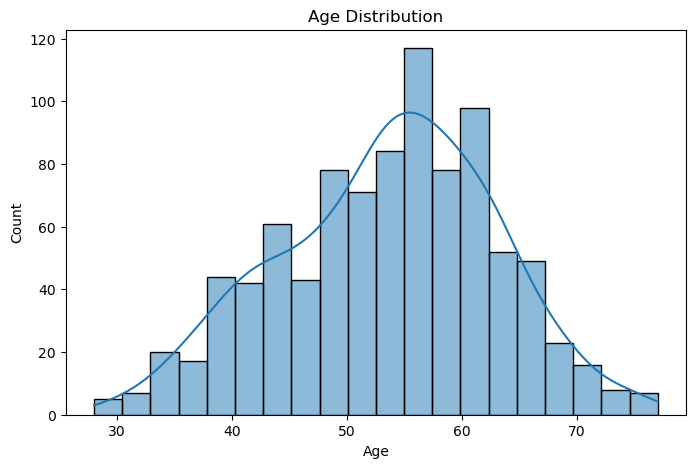

In [610]:
#  Age distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


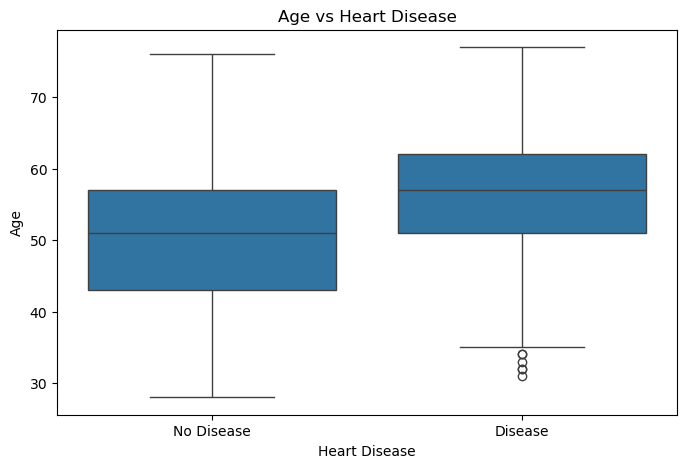

In [611]:
#  Age vs heart disease

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="target", y="age")
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

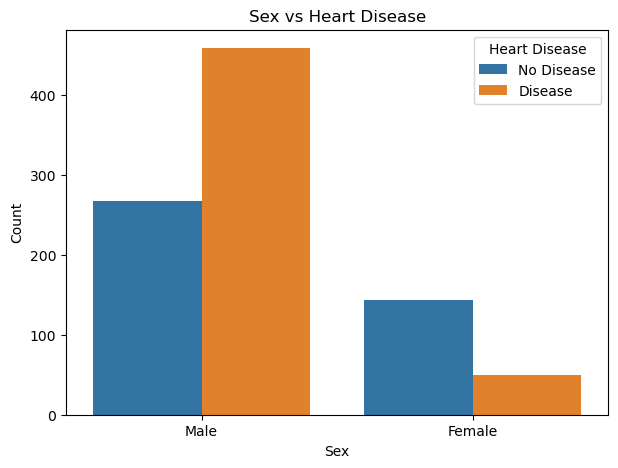

In [612]:
#  Sex vs heart disease

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sex", hue="target")
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()



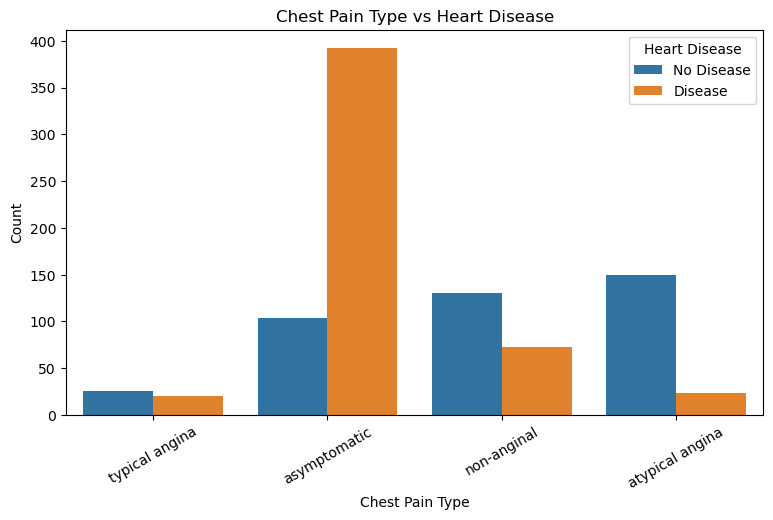

In [613]:

# Chest pain type vs heart disease

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="cp", hue="target")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()


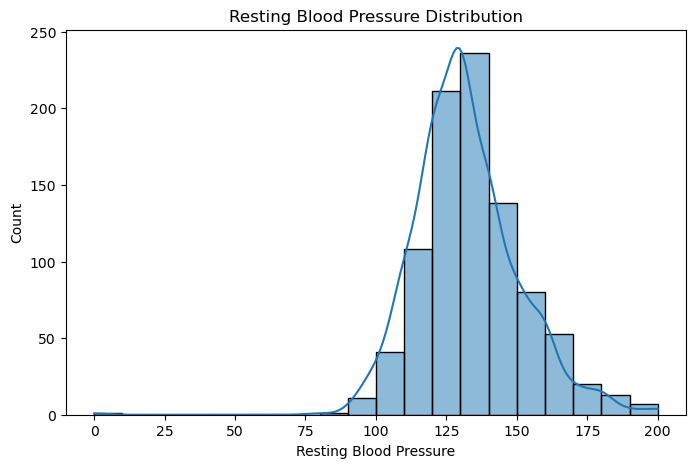

In [614]:
# Resting blood pressure distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="trestbps", bins=20, kde=True)
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Count")
plt.show()

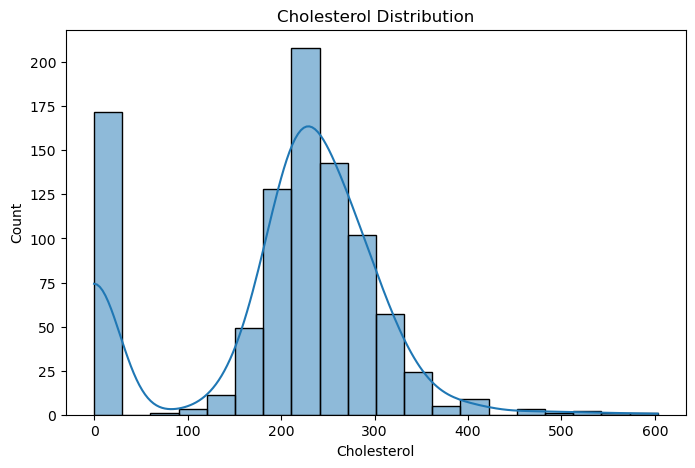

In [615]:
# Cholesterol distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="chol", bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

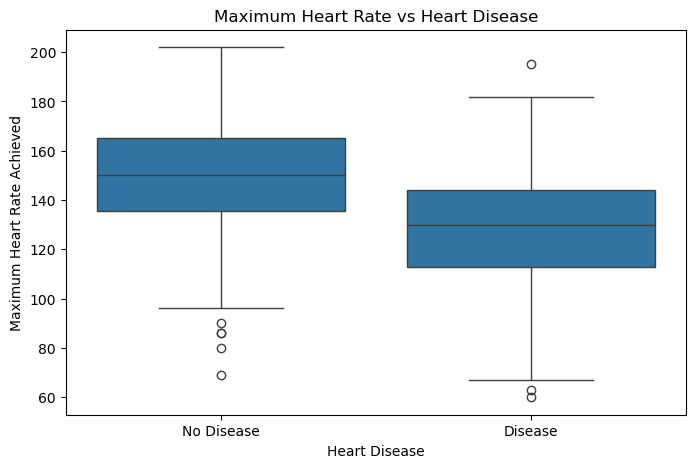

In [616]:
# Maximum heart rate vs heart disease

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="target", y="thalch")
plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate Achieved")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

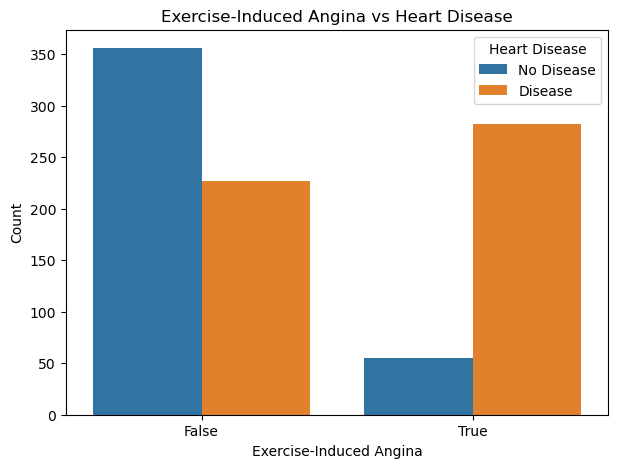

In [617]:
# 14. Exercise-induced angina vs heart disease

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="exang", hue="target")
plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()

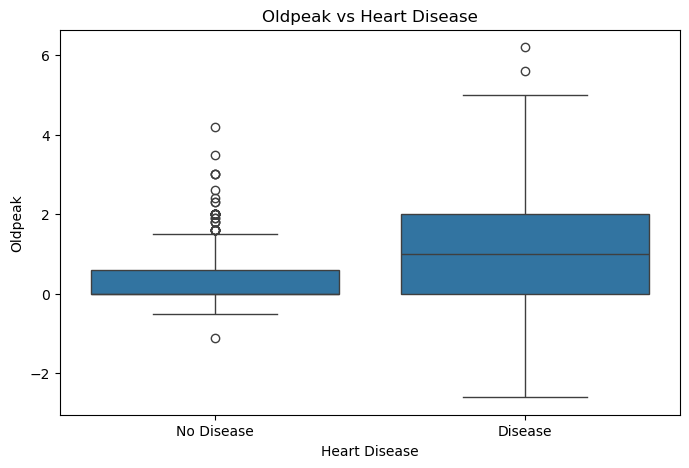

In [618]:
# Oldpeak vs heart disease

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="target", y="oldpeak")
plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Oldpeak")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

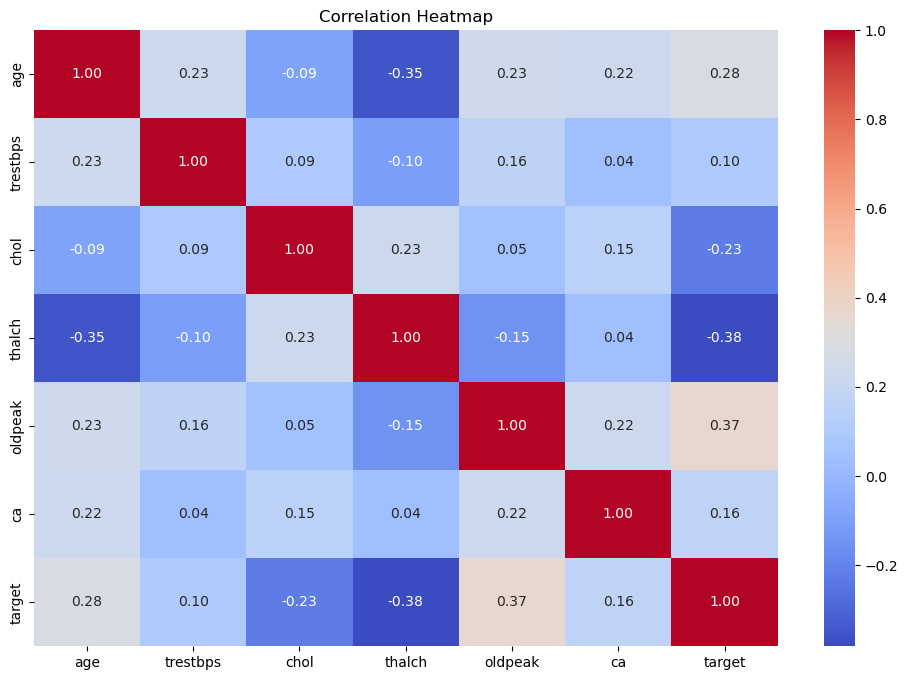

In [619]:
# 16. Correlation heatmap
# Only numeric columns are used

plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

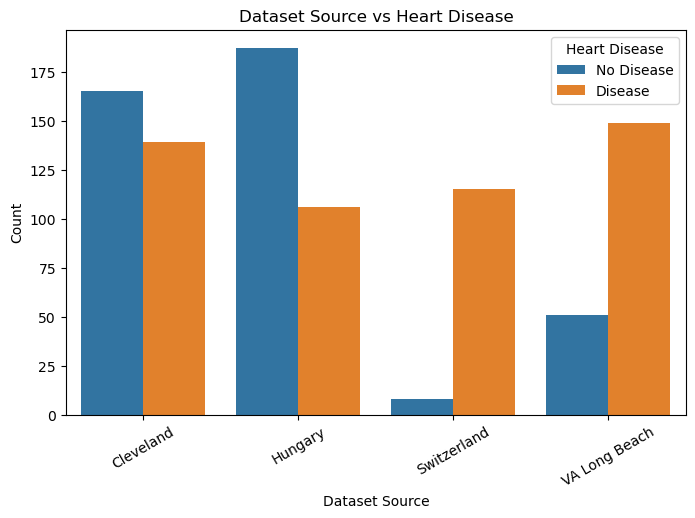

In [620]:
# 17. Dataset source comparison

if "dataset" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x="dataset", hue="target")
    plt.title("Dataset Source vs Heart Disease")
    plt.xlabel("Dataset Source")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
    plt.show()

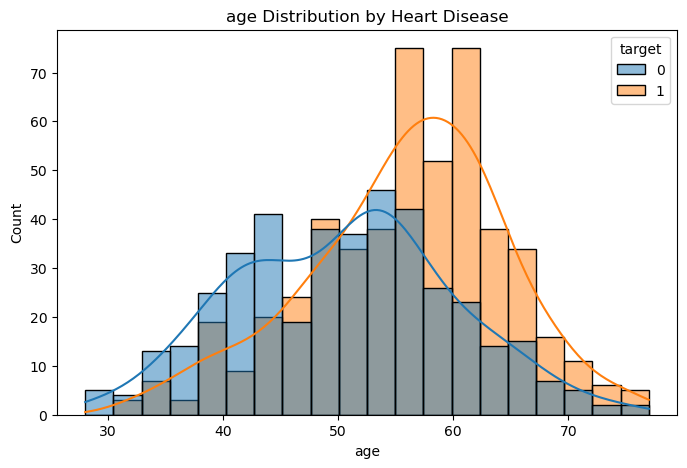

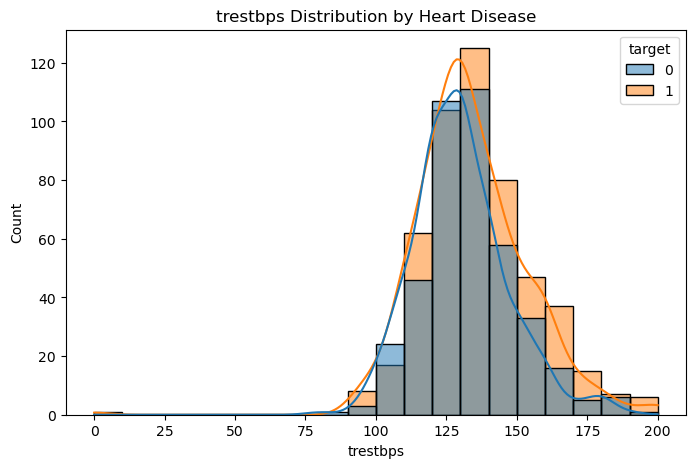

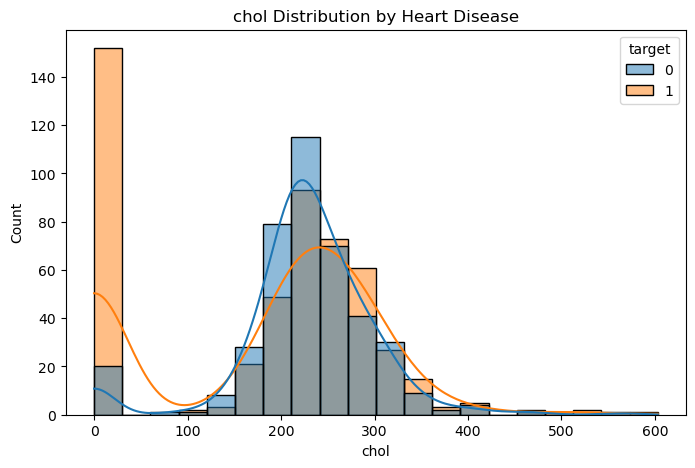

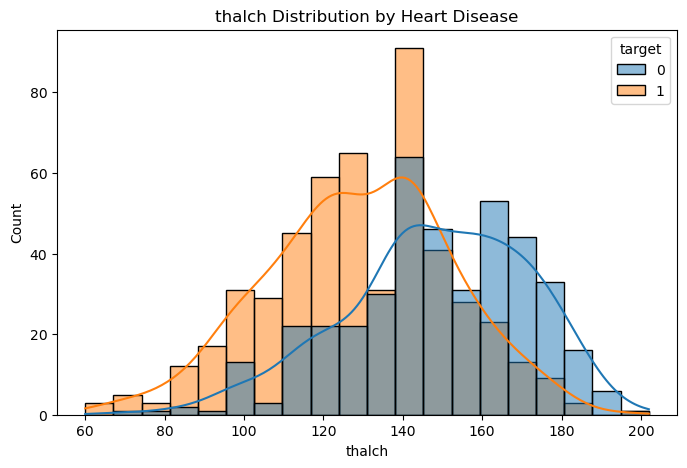

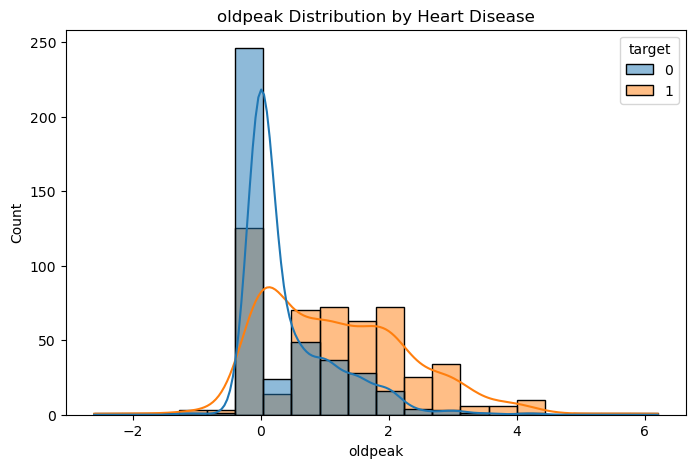

In [621]:
# 18. Numeric feature distributions by target

selected_numeric = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for col in selected_numeric:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(data=df, x=col, hue="target", kde=True, bins=20)
        plt.title(f"{col} Distribution by Heart Disease")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()


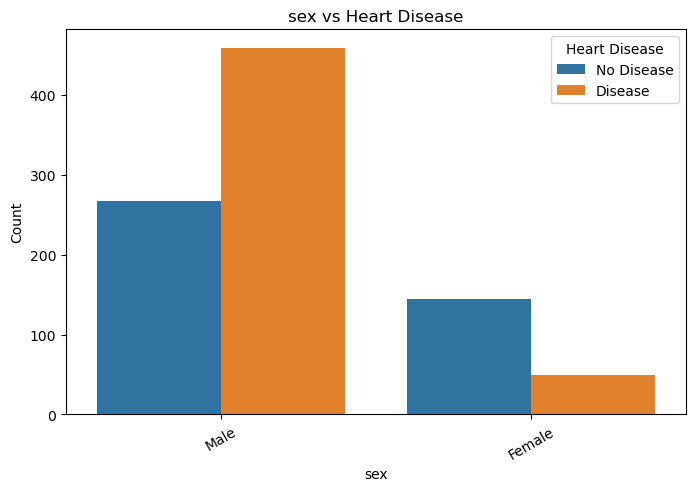

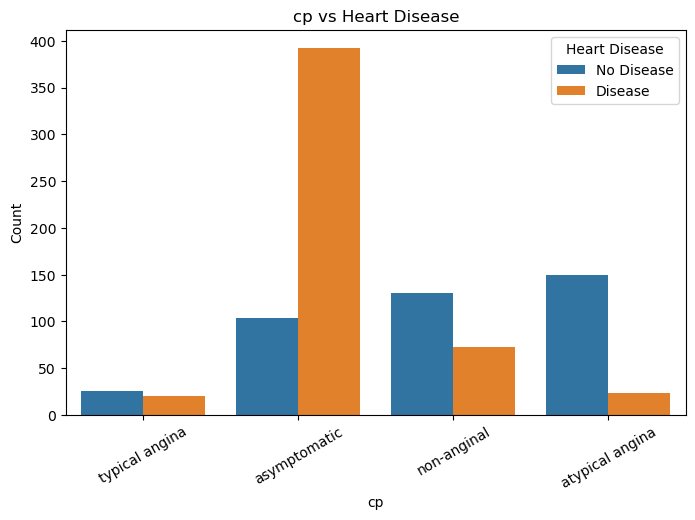

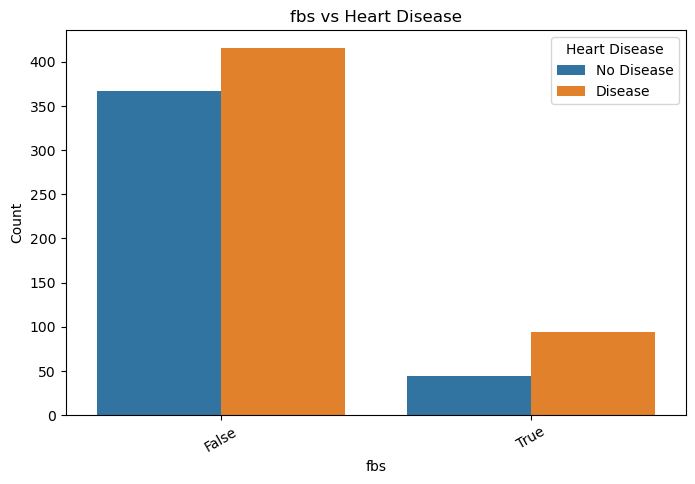

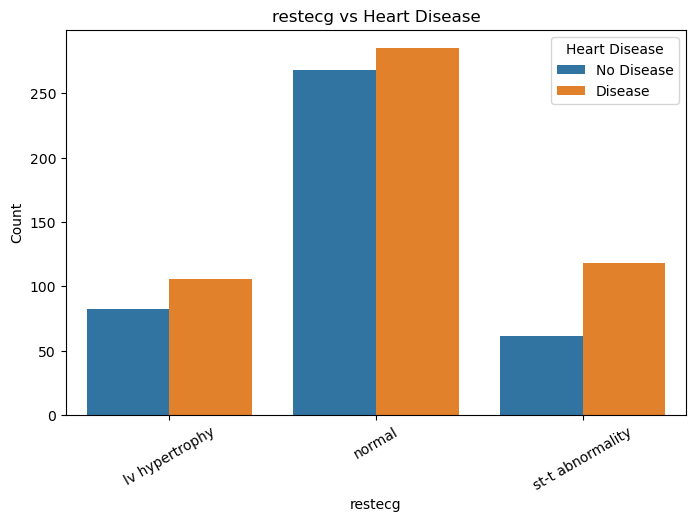

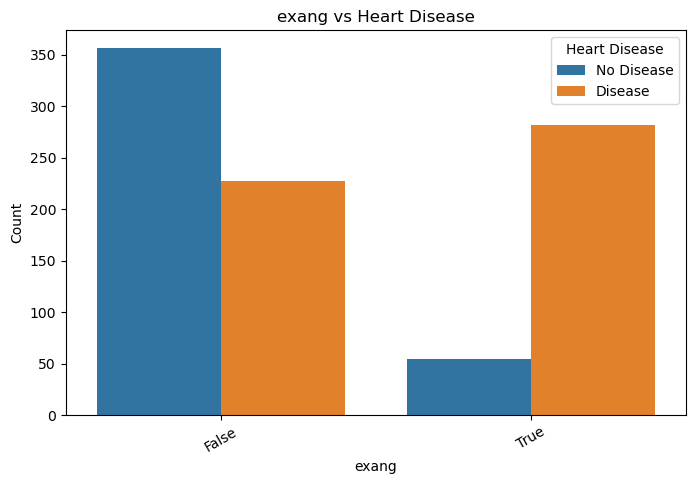

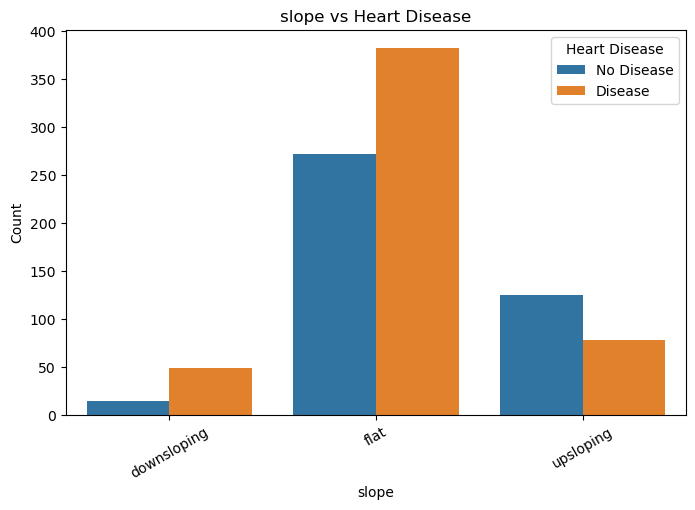

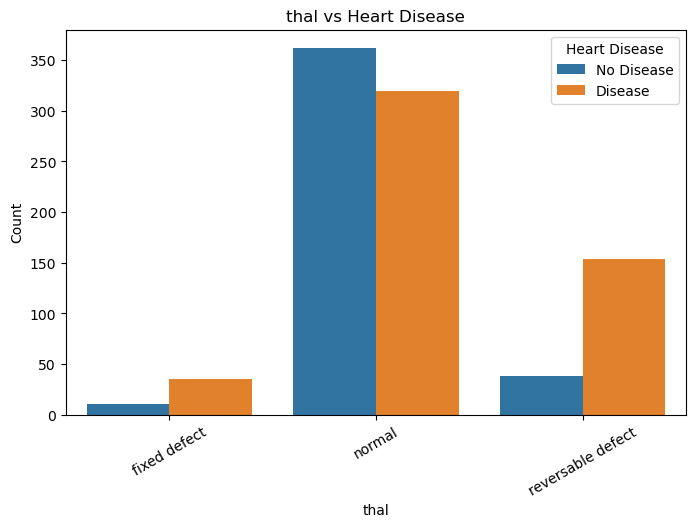

In [622]:
# Categorical feature counts by target

selected_categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in selected_categorical:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=col, hue="target")
        plt.title(f"{col} vs Heart Disease")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=30)
        plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
        plt.show()

## KNN Model

In [623]:
                                          # KNN Model: Heart Disease Prediction
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

df = df.dropna()


In [624]:
# Create binary target variable
# In this dataset:
# num = 0 means no heart disease
# num = 1, 2, 3, or 4 means heart disease is present

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

# 2. Split features and target

X = df.drop(columns=["target", "target"])
y = df["target"]

# Drop id column if it exists because it is only an identifier
if "id" in X.columns:
    X = X.drop(columns=["id"])

In [625]:
# Identify numerical and categorical columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns

print("Numerical columns:")
print(list(numerical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical columns:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [626]:
# Preprocessing
# KNN needs numbers only.
# Numerical columns are scaled.
# Categorical columns are one-hot encoded.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [627]:
# KNN pipeline

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier())
    ]
)

In [628]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [629]:
# Tuning KNN hyperparameters
param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest KNN Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 4))


Best KNN Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 18, 'knn__weights': 'distance'}

Best Cross-Validation Accuracy:
0.8383


In [630]:
# Make Prediction 
best_knn_model = grid_search.best_estimator_

y_pred = best_knn_model.predict(X_test)
y_pred_proba = best_knn_model.predict_proba(X_test)[:, 1]


In [631]:
# Evaluating the Model 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nKNN Model Performance:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


KNN Model Performance:
Accuracy: 0.8587
Precision: 0.8654
Recall: 0.8824
F1 Score: 0.8738
ROC-AUC: 0.924

Confusion Matrix:
[[68 14]
 [12 90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        82
           1       0.87      0.88      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



## Random Forest

In [632]:
##  Preparing Features
# separate target first
X = df.drop('target', axis=1)
y = df['target']

# one-hot encode all categorical/text columns
X = pd.get_dummies(X, drop_first=True)

In [633]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [634]:
# Training Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Making Predictions

In [635]:
# Getting Y precidted and probability
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [636]:
# Calculating Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.842391304347826
Precision: 0.8348623853211009
Recall: 0.8921568627450981
F1-score: 0.8625592417061612


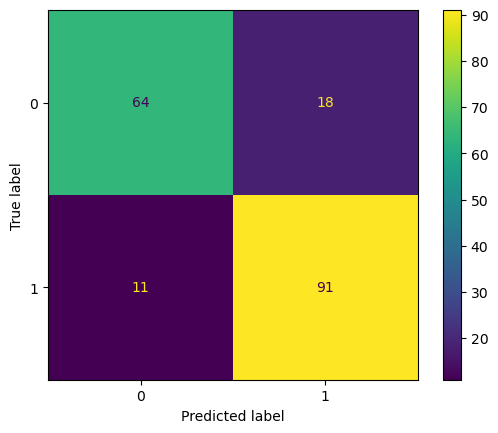

In [637]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

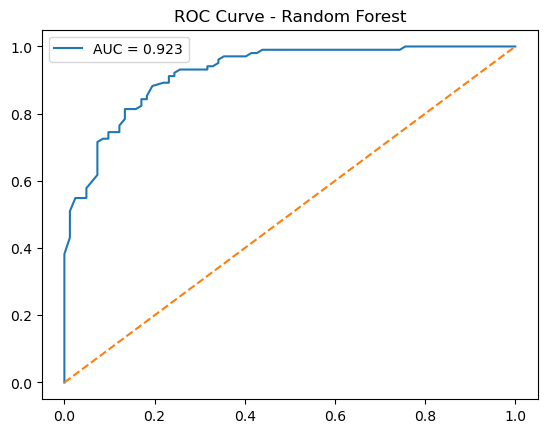

In [638]:
# AUC score and ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC Curve - Random Forest")
plt.show()

In [639]:
# Feature Importance

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

chol                  0.133825
thalch                0.126551
age                   0.114566
oldpeak               0.103317
exang                 0.084502
trestbps              0.071717
cp_atypical angina    0.062668
sex_Male              0.041064
thal_normal           0.032349
cp_non-anginal        0.030581
dtype: float64


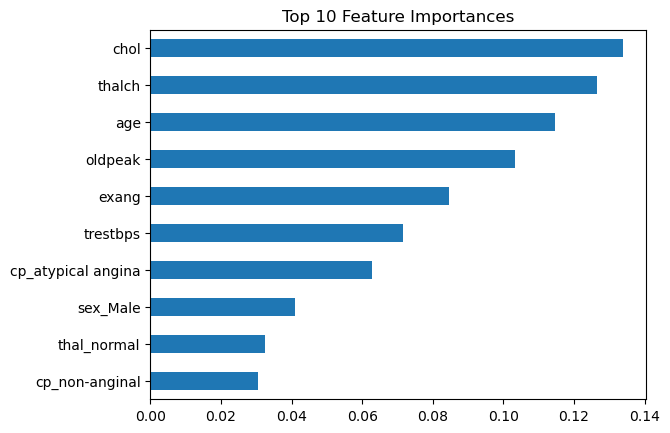

In [640]:
# Feature Importance Plot
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

## Logistic Regression


In [641]:
print(f'Features : {X.shape[1]} columns')
print(f'Samples  : {X.shape[0]}')
print(f'Target   : {y.name}  |  unique values: {sorted(y.unique())}')

X.head(10)

Features : 21 columns
Samples  : 920
Target   : target  |  unique values: [np.int64(0), np.int64(1)]


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,dataset_Hungary,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,True,False,...,False,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,True,False,...,False,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,True,False,...,False,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,True,False,...,False,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,False,False,...,False,True,False,False,False,False,False,True,True,False
5,56,120.0,236.0,False,178.0,False,0.8,0.0,True,False,...,False,True,False,False,True,False,False,True,True,False
6,62,140.0,268.0,False,160.0,False,3.6,2.0,False,False,...,False,False,False,False,False,False,False,False,True,False
7,57,120.0,354.0,False,163.0,True,0.6,0.0,False,False,...,False,False,False,False,True,False,False,True,True,False
8,63,130.0,254.0,False,147.0,False,1.4,1.0,True,False,...,False,False,False,False,False,False,True,False,False,True
9,53,140.0,203.0,True,155.0,True,3.1,0.0,True,False,...,False,False,False,False,False,False,False,False,False,True


In [642]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class balance in both splits
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows') 

Train size : 736 rows
Test size  : 184 rows


In [643]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")


lr = lr_pipeline.named_steps['model']
print('Pipeline trained.')
print(f'Solver     : {lr.solver}')
print(f'Iterations : {lr.n_iter_[0]}')
print(f'Classes    : {lr.classes_}')

Logistic Regression trained successfully.
Pipeline trained.
Solver     : lbfgs
Iterations : 14
Classes    : [0 1]


In [644]:
# Pass raw X_test — the pipeline handles preprocessing internally
y_pred      = lr_pipeline.predict(X_test)
y_pred_prob = lr_pipeline.predict_proba(X_test)[:, 1]  # probability for the positive class

# Quick peek at predictions
pred_df = pd.DataFrame({
    'actual'     : y_test.values,
    'predicted'  : y_pred,
    'prob_class1': y_pred_prob.round(3)
})
pred_df.head(10)

,actual,predicted,prob_class1
0,1,0,0.358
1,1,1,0.977
2,1,1,0.908
3,1,1,0.965
4,0,1,0.630
5,0,1,0.674
6,0,0,0.322
7,1,1,0.943
8,0,0,0.112
9,1,1,0.836


In [645]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy : 0.8370
ROC-AUC  : 0.9213

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



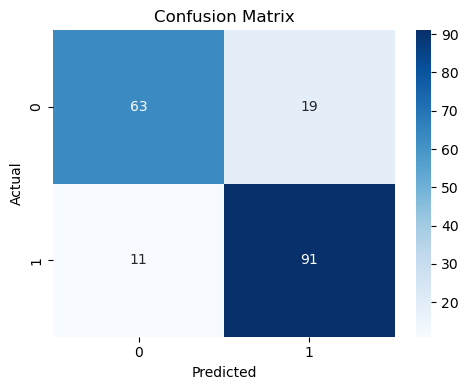

In [646]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr.classes_,
    yticklabels=lr.classes_,
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [647]:
lr = lr_pipeline.named_steps["model"]

feature_names = X_train.columns

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr.coef_[0],
    "odds_ratio": np.exp(lr.coef_[0])
}).sort_values("coefficient", key=abs, ascending=False)

print("Feature importance by absolute coefficient:")
coef_df

Feature importance by absolute coefficient:


,feature,coefficient,odds_ratio
10,dataset_Switzerland,1.293912,3.647024
7,ca,0.716865,2.048004
12,cp_atypical angina,-0.708645,0.492311
6,oldpeak,0.625548,1.869269
11,dataset_VA Long Beach,0.545429,1.725348
5,exang,0.515885,1.675121
8,sex_Male,0.463632,1.589838
17,slope_flat,0.438614,1.550557
13,cp_non-anginal,-0.425603,0.653376
9,dataset_Hungary,0.240902,1.272397


Now optimize parameters for better results

In [648]:
baseline_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_base      = baseline_pipeline.predict(X_test)
y_pred_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_pred_prob_base)

print(f'Baseline  Accuracy : {baseline_acc:.4f}')
print(f'Baseline  ROC-AUC  : {baseline_auc:.4f}')

Baseline  Accuracy : 0.8370
Baseline  ROC-AUC  : 0.9213


In [649]:
from sklearn.model_selection import GridSearchCV

# Pipeline keys follow the pattern  <step_name>__<param_name>
param_grid = {
    'model__C'            : [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty'      : ['l1', 'l2'],
    'model__solver'       : ['liblinear'],   # supports both l1 and l2
    'model__class_weight' : [None, 'balanced']
}

tuning_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

grid_search = GridSearchCV(
    estimator  = tuning_pipeline,
    param_grid = param_grid,
    cv         = 5,                # 5-fold stratified CV
    scoring    = 'roc_auc',        # optimise for AUC; change to 'f1' or 'accuracy' if preferred
    n_jobs     = -1,               # use all available CPU cores
    verbose    = 1,
    refit      = True              # refit best params on full X_train after search
)

grid_search.fit(X_train, y_train)

print('\nBest parameters found:')
for param, value in grid_search.best_params_.items():
    print(f'  {param:<30} : {value}')
print(f'\nBest cross-val ROC-AUC : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters found:
  model__C                       : 1
  model__class_weight            : None
  model__penalty                 : l1
  model__solver                  : liblinear

Best cross-val ROC-AUC : 0.9007


/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

In [650]:
# Inspect full CV results as a sorted DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = ['param_model__C', 'param_model__penalty',
        'param_model__class_weight',
        'mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score').head(10)

,param_model__C,param_model__penalty,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
12,1.0,l1,None,0.900695,0.024401,1
14,1.0,l1,balanced,0.900360,0.024427,2
22,100.0,l1,balanced,0.900246,0.024528,3
11,0.1,l2,balanced,0.900211,0.023262,4
19,10.0,l2,balanced,0.900208,0.024500,5
23,100.0,l2,balanced,0.900208,0.024500,5
18,10.0,l1,balanced,0.900208,0.024344,7
20,100.0,l1,None,0.900059,0.024585,8
21,100.0,l2,None,0.900059,0.024585,8
16,10.0,l1,None,0.900022,0.024580,10


In [651]:
best_pipeline = grid_search.best_estimator_

y_pred      = best_pipeline.predict(X_test)
y_pred_prob = best_pipeline.predict_proba(X_test)[:, 1]

pred_df = pd.DataFrame({
    'actual'     : y_test.values,
    'predicted'  : y_pred,
    'prob_class1': y_pred_prob.round(3)
})
pred_df.head(10)

,actual,predicted,prob_class1
0,1,0,0.354
1,1,1,0.977
2,1,1,0.901
3,1,1,0.964
4,0,1,0.602
5,0,1,0.668
6,0,0,0.340
7,1,1,0.937
8,0,0,0.111
9,1,1,0.832


In [652]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_pred_prob)

comparison = pd.DataFrame({
    'Metric'   : ['Accuracy', 'ROC-AUC'],
    'Baseline' : [round(baseline_acc, 4), round(baseline_auc, 4)],
    'Tuned'    : [round(tuned_acc, 4),    round(tuned_auc, 4)],
})
comparison['Delta'] = (comparison['Tuned'] - comparison['Baseline']).round(4)
print(comparison.to_string(index=False))

print('\nClassification Report (tuned model):')
print(classification_report(y_test, y_pred))

  Metric  Baseline  Tuned  Delta
Accuracy    0.8370 0.8370 0.0000
 ROC-AUC    0.9213 0.9219 0.0006

Classification Report (tuned model):
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184

